## Online Shopping Intention Analysis with Clustering

<img src="https://media2.dev.to/dynamic/image/width=1000,height=420,fit=cover,gravity=auto,format=auto/https%3A%2F%2Fdev-to-uploads.s3.amazonaws.com%2Fuploads%2Farticles%2Frrtxj28t4g4h7optw447.jpg">

## Data Dictionary 

Administrative: This is the number of pages of this type (administrative) that the user visited.

Administrative_Duration: This is the amount of time spent in this category of pages.

Informational: This is the number of pages of this type (informational) that the user visited.

Informational_Duration: This is the amount of time spent in this category of pages.

ProductRelated: This is the number of pages of this type (product related) that the user visited.

ProductRelated_Duration: This is the amount of time spent in this category of pages.

BounceRates: The percentage of visitors who enter the website through that page and exit without triggering any additional tasks.

ExitRates: The percentage of pageviews on the website that end at that specific page.

PageValues: The average value of the page averaged over the value of the target page and/or the completion of an eCommerce transaction.
More information about how this is calculated

SpecialDay: This value represents the closeness of the browsing date to special days or holidays (eg Mother's Day or Valentine's day) in which the transaction is more likely to be finalized. More information about how this value is calculated below.

Month: Contains the month the pageview occurred, in string form.

OperatingSystems: An integer value representing the operating system that the user was on when viewing the page.

Browser: An integer value representing the browser that the user was using to view the page.

Region: An integer value representing which region the user is located in.

TrafficType: An integer value representing what type of traffic the user is categorized into.
Read more about traffic types here.

VisitorType: A string representing whether a visitor is New Visitor, Returning Visitor, or Other.

Weekend: A boolean representing whether the session is on a weekend.

Revenue: A boolean representing whether or not the user completed the purchase.

## Aim
The primary goal is to use Unsupervised Learning to group online shopping sessions based on user behavior. Instead of just looking at who bought something, we want to discover the natural segments of visitors based on how they navigate the website.

By applying K-Means Clustering, we aim to see if the machine can automatically distinguish between:

*Window Shoppers:* Users who spend time on general pages but don't look at specific products.

*Informational Seekers:* Users who spend a lot of time checking "About Us," "Contact," or "Shipping" pages.

*High-Intent Shoppers:* Users who go straight to product pages and spend significant time there.

## Target

The "Target" in a clustering project is slightly different than in regression or classification because we don't have a *y* label to predict. Instead, your targets for this assignment are:

*Mathematical Target:* Find the Optimal Number of Clusters (*k*); your target is to find the point where the Silhouette Score is highest.

*Business Target:* Define Actionable Personas. After clustering, your target is to describe who is in each group. For example: "Cluster 0 represents users who visited 10+ product pages but stayed for less than 5 minutes—these are likely 'Quick Browsers'."

*Technical Target:* To create a Visualization (like a 2D Scatter Plot) that clearly shows the separation between these different types of shoppers.

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Reading Dataset & Dataframe Generation

In [2]:
#I have created my notebook on Kaggle, so that I will not need to download data from the website and take advantage of Kaggle's infrastructure. 

df = pd.read_csv('/kaggle/input/datasets/henrysue/online-shoppers-intention/online_shoppers_intention.csv')

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Exploratory Data Analysis

In [4]:
df.shape

(12330, 18)

In [5]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

In [6]:
df.tail()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False
12329,0,0.0,0,0.0,3,21.250000,0.000000,0.066667,0.000000,0.0,Nov,3,2,1,2,New_Visitor,True,False


In [7]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [8]:
df.Administrative.value_counts()

Administrative
0     5768
1     1354
2     1114
3      915
4      765
5      575
6      432
7      338
8      287
9      225
10     153
11     105
12      86
13      56
14      44
15      38
16      24
17      16
18      12
19       6
24       4
22       4
23       3
21       2
20       2
27       1
26       1
Name: count, dtype: int64

## Clustering

In [9]:
# Feature Selection: Administrative, Informational, and ProductRelated Durations

x = df[['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']]

In [10]:
model=KMeans(4)

In [11]:
model=model.fit(x)

In [12]:
prediction=model.predict(x)

In [13]:
x['cluster']=prediction

In [14]:
x.head()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,cluster
0,0.0,0.0,0.000000,0
1,0.0,0.0,64.000000,0
2,0.0,0.0,0.000000,0
3,0.0,0.0,2.666667,0
4,0.0,0.0,627.500000,0


In [15]:
x.sample()

,Administrative_Duration,Informational_Duration,ProductRelated_Duration,cluster
10490,0.0,0.0,62.5,0


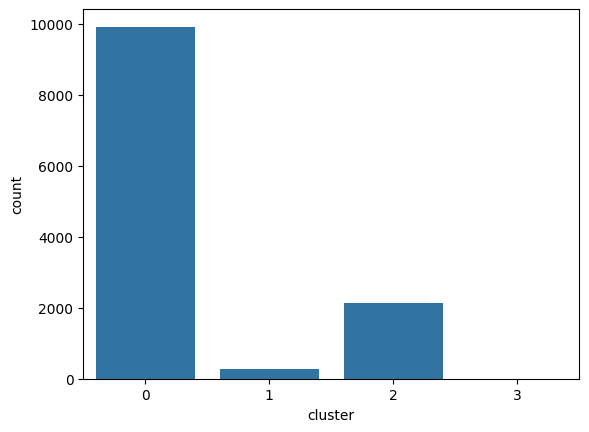

In [16]:
sns.countplot(x=x['cluster']);

In [17]:
silhouette_score(x,prediction)

np.float64(0.684721053060102)

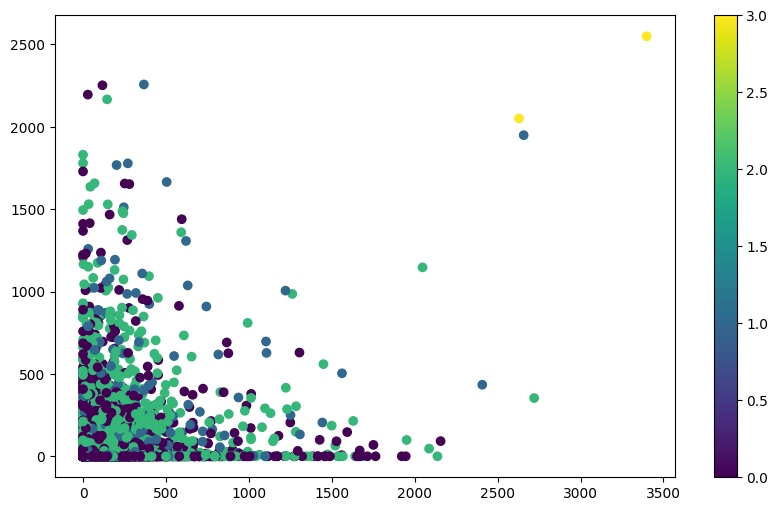

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(x.Administrative_Duration, x.Informational_Duration, c=prediction)
plt.colorbar();

In [19]:
# wcss = within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    prediction=model.predict(x)
    ss1=silhouette_score(x,prediction)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.7817169147595664
0.6951141388998338
0.6719639298565198
0.6232911352313669
0.619483152581766
0.5894828275120407
0.5602664232737969
0.5452301253731633


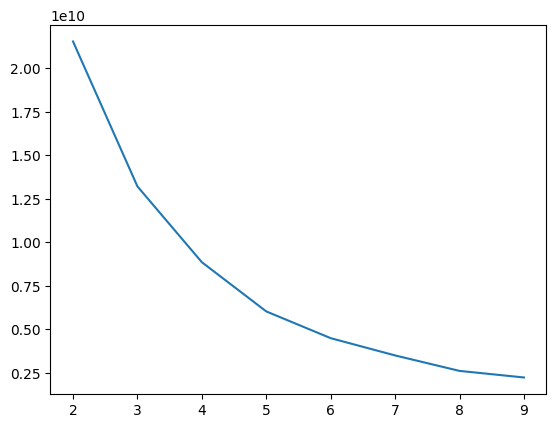

In [20]:
plt.plot(range(2,10),wcss);

In [21]:
from yellowbrick.cluster import KElbowVisualizer

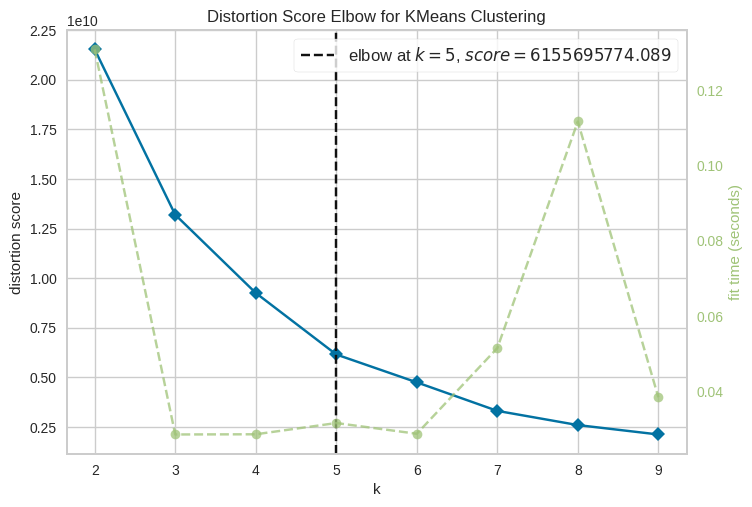

In [22]:
vis=KElbowVisualizer(KMeans(),k=(2,10))
vis.fit(x)
vis.show();

## Conclusion

In this project, we successfully applied K-Means Clustering to identify distinct groups of online shoppers based on their browsing behavior. By selecting key features such as Administrative, Informational, and Product Related Durations, we were able to observe how different users interact with the platform.

Following the methodology from our class, we used the Silhouette Score to mathematically determine the most appropriate number of clusters. By identifying the point where the score was optimized, we ensured that the resulting groups were as distinct and well-separated as possible. This project demonstrates how Unsupervised Learning can reveal hidden patterns in complex datasets without the need for pre-defined labels.

## HuggingFace Link

https://huggingface.co/spaces/basaktamer/Online_Shopping_Intention_Analysis_with_Clustering